NOAA NCEI Climate At A Glance
Temperature and Precipitation Extremes Analysis
Becky Bolinger, 2026

In [1]:
## Install and important necessary libraries

# pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from states import state_dict
from states import state_to_abbrev


In [116]:
# Make selections for state, month, and timescale
state_input = 'Colorado'

month = 'March'
timescale = '6-month'  # Options: '1-month', '2-month', ..., '12-month'

In [117]:
## Based on parameters, build the URLs for temperature and precipitation data
base_url = "https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/statewide/time-series/"

# State selection
name_to_id_dict = {name: state_num for state_num, name in state_dict.items()} # reverse dictionary selection
state_num = name_to_id_dict.get(state_input) # state number for URL

state_id = state_to_abbrev.get(state_input) # 2-letter state abbreviation for labeling

# months and timescale selection
month_dict = {
    'January': '1',
    'February': '2',
    'March': '3',
    'April': '4',
    'May': '5',
    'June': '6',
    'July': '7',
    'August': '8',
    'September': '9',
    'October': '10',
    'November': '11',
    'December': '12'
}
month_num = month_dict.get(month)
end_index = list(month_dict.keys()).index(month)  # Adjust for 0-based indexing in Python lists

short_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

timescale_dict = {
    '1-month': '1',
    '2-month': '2',
    '3-month': '3',
    '4-month': '4',
    '5-month': '5',
    '6-month': '6',
    '7-month': '7',
    '8-month': '8',
    '9-month': '9',
    '10-month': '10',
    '11-month': '11',
    '12-month': '12'
}
timescale_num = timescale_dict.get(timescale)

## build the timescale label for plots
if timescale_num == '1':
    time_label = month
else:
    start_index = (end_index - int(timescale_num) + 1) % 12  # Calculate the starting month index, wrap around using modulo
    time_label = f"{short_months[start_index]}-{short_months[end_index]}"

# print(time_label)  # This will print something like "March" for 1-month or "Jan-Mar" for 3-month

# Build URLs
urlTemp = f"{base_url}{state_num}/tavg/{timescale_num}/{month_num}/1895-2026/data.csv"
urlPrecip = f"{base_url}{state_num}/pcp/{timescale_num}/{month_num}/1895-2026/data.csv"


In [118]:

## Read in Climate at a Glance data from URLs

# NOAA Climate at a Glance CSVs typically have 2 rows of metadata at the top.
# We skip those so pandas reads the actual 'Date' and 'Value' headers correctly.
dfTemp = pd.read_csv(urlTemp, skiprows=2)
dfPrecip = pd.read_csv(urlPrecip, skiprows=2)

# The 'Date' column is formatted as YYYYMM (e.g., 202603). 
# We'll extract just the 4-digit Year.
dfTemp['Year'] = dfTemp['Date'].astype(str).str[:4].astype(int)

# Rename the 'Value' columns before merging to avoid confusion
dfPrecip = dfPrecip.rename(columns={'Value': 'Precip_Value'})
dfTemp = dfTemp.rename(columns={'Value': 'Temp_Value'})

# Merge the temperature and precipitation data and store in df with the year
df_merged = pd.merge(dfTemp, dfPrecip, on='Date', how='inner')

df = df_merged[['Year', 'Temp_Value', 'Precip_Value']]

df.head()

recent_year = df['Year'].max()
min_year = df['Year'].min()



The next cell takes all temperature measurements in the data and plots a distribution, highlighting the 20th century average, the NOAA climate normals (1991-2020), and the current month's position (in this case, March 2026). 

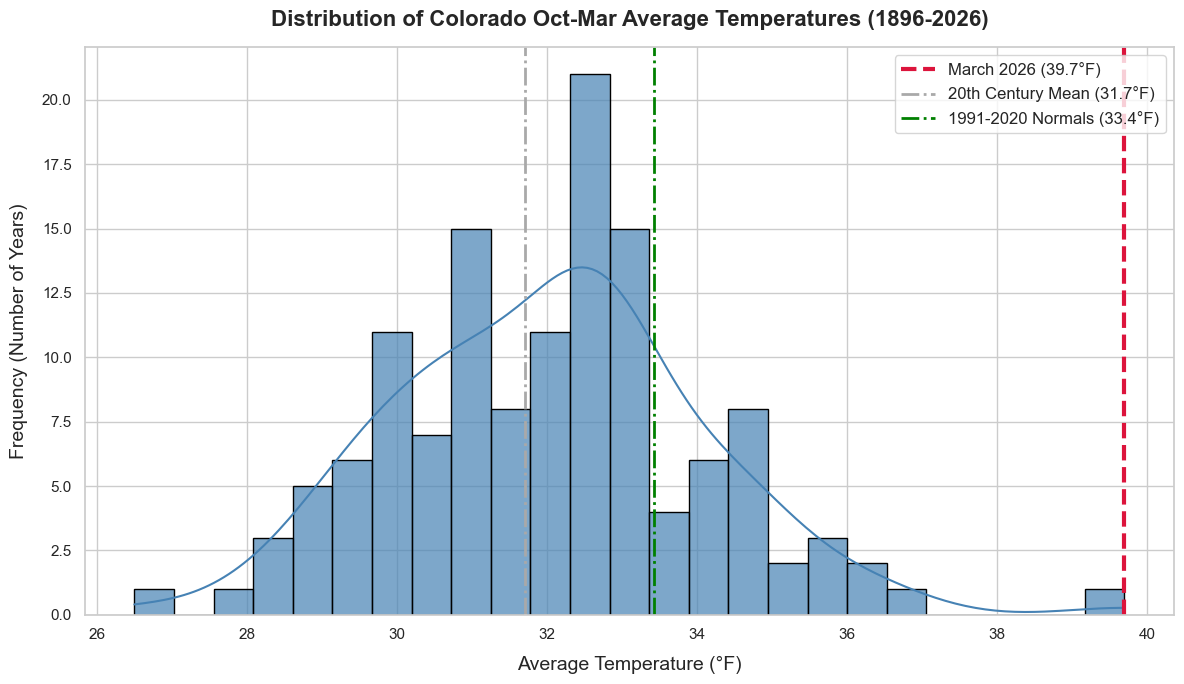

In [120]:
# Extract the specific temperature value for the most recent year to highlight in the histogram
temp_recent_data = df.loc[df['Year'] == recent_year, 'Temp_Value'].values
temp_recent = temp_recent_data[0] if len(temp_recent_data) > 0 else None

temp_mean_20th_century = df.loc[(df['Year'] >= 1901) & (df['Year'] <= 2000), 'Temp_Value'].mean()
temp_normals = df.loc[(df['Year'] >= 1991) & (df['Year'] <= 2020), 'Temp_Value'].mean()

# Set up the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Plot the histogram of all temperatures (1895-current)
sns.histplot(
    df['Temp_Value'], 
    bins=25, 
    kde=True, # Adds a smooth distribution curve
    color='steelblue', 
    edgecolor='black',
    alpha=0.7
)

# Highlight the most recent temperature if it exists in the dataset
if temp_recent is not None:
    plt.axvline(
        x=temp_recent, 
        color='crimson', 
        linestyle='--', 
        linewidth=3, 
        label=f'{month} {recent_year} ({temp_recent:.1f}°F)'
    )

# Highlight 20th century mean and 1991-2020 normals
plt.axvline(
    x=temp_mean_20th_century, 
    color='darkgrey', 
    linestyle='-.', 
    linewidth=2, 
    label=f'20th Century Mean ({temp_mean_20th_century:.1f}°F)'
)
plt.axvline(
    x=temp_normals, 
    color='green', 
    linestyle='-.', 
    linewidth=2, 
    label=f'1991-2020 Normals ({temp_normals:.1f}°F)'
)

plt.legend(fontsize=12, loc='upper right')

# Add titles and labels
plt.title(f'Distribution of {state_input} {time_label} Average Temperatures ({min_year}-{recent_year})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Temperature (°F)', fontsize=14, labelpad=10)
plt.ylabel('Frequency (Number of Years)', fontsize=14, labelpad=10)

# Final layout adjustments
plt.tight_layout()

# Save the figure to your current directory and display it
outfile = f'images/{state_id}_{month_num}_{timescale_num}_temp_histogram.png'
plt.savefig(outfile, dpi=300)
plt.show()

In this next cell, we're going to use precipitation data too and generate a quadrant chart with both temperature and precipitation.

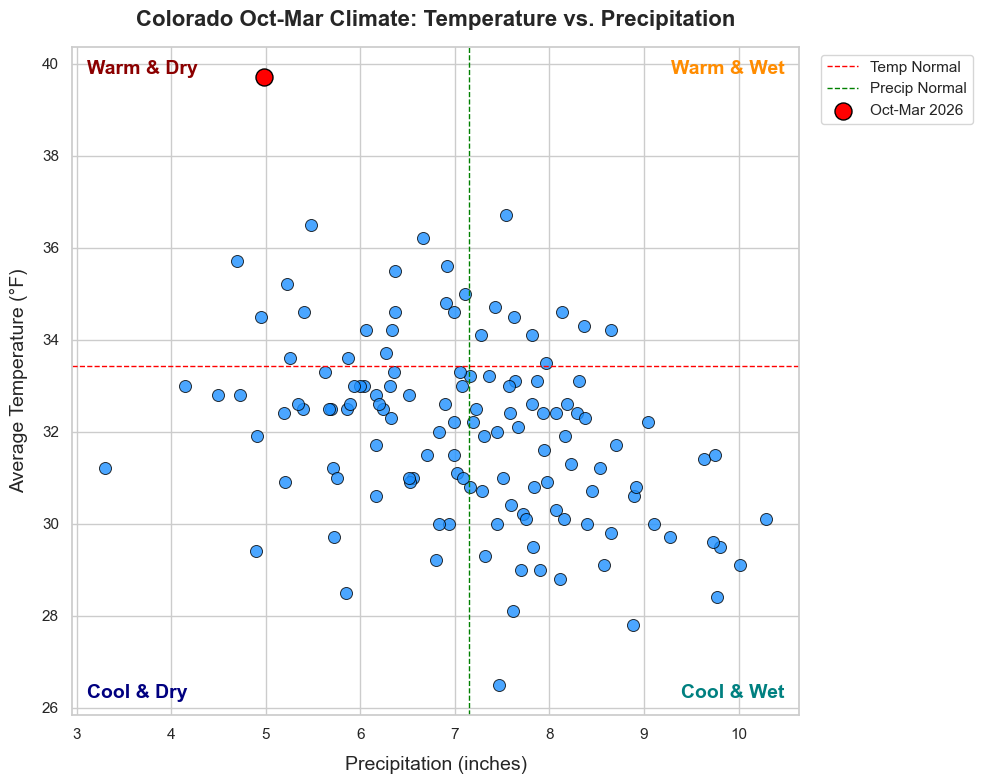

In [121]:
# Extract the specific p value for 2026
precip_recent_data = df.loc[df['Year'] == recent_year, 'Precip_Value'].values
precip_recent = precip_recent_data[0] if len(precip_recent_data) > 0 else None

precip_mean_20th_century = df.loc[(df['Year'] >= 1901) & (df['Year'] <= 2000), 'Precip_Value'].mean()
precip_normals = df.loc[(df['Year'] >= 1991) & (df['Year'] <= 2020), 'Precip_Value'].mean()

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 1. Create the scatter plot
sns.scatterplot(
    data=df, 
    x='Precip_Value', 
    y='Temp_Value', 
    color='dodgerblue',
    edgecolor='black',
    s=75, # Marker size
    alpha=0.8
)

# 2. Add the dashed lines for the normals
plt.axhline(y=temp_normals, color='red', linestyle='--', linewidth=1, label='Temp Normal')
plt.axvline(x=precip_normals, color='green', linestyle='--', linewidth=1, label='Precip Normal')

# 3. Add Quadrant Labels using Axes coordinates (0 to 1 scale)
# va='top'/'bottom' and ha='left'/'right' ensure the text aligns cleanly into the corners
plt.text(0.02, 0.98, 'Warm & Dry', transform=plt.gca().transAxes, fontsize=14, color='darkred', fontweight='bold', va='top', ha='left')
plt.text(0.98, 0.98, 'Warm & Wet', transform=plt.gca().transAxes, fontsize=14, color='darkorange', fontweight='bold', va='top', ha='right')
plt.text(0.02, 0.02, 'Cool & Dry', transform=plt.gca().transAxes, fontsize=14, color='navy', fontweight='bold', va='bottom', ha='left')
plt.text(0.98, 0.02, 'Cool & Wet', transform=plt.gca().transAxes, fontsize=14, color='teal', fontweight='bold', va='bottom', ha='right')

# 4. Optional: Highlight 2026 so it stands out!
year_recent_df = df[df['Year'] == recent_year]
if not year_recent_df.empty:
    plt.scatter(
        year_recent_df['Precip_Value'], 
        year_recent_df['Temp_Value'], 
        color='red', 
        s=150, # Make it larger
        edgecolor='black', 
        zorder=5, # Ensure it draws on top of other points
        label=f'{time_label} {recent_year}'
    )

# 5. Dynamic Titles and labels
plt.title(f'{state_input} {time_label} Climate: Temperature vs. Precipitation', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Precipitation (inches)', fontsize=14, labelpad=10)
plt.ylabel('Average Temperature (°F)', fontsize=14, labelpad=10)
# Move the legend outside the plot so it doesn't cover your points or quadrant labels
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# Final layout adjustments
plt.tight_layout()

# Save and show
outfile = f'images/{state_id}_{month_num}_{timescale_num}_temp_precip_quadrants.png'
plt.savefig(outfile, dpi=300)
plt.show()

Next we're going to do some statistical analysis by calculating some joint probability distributions to see how likely the specific period is to occur today vs. historical time periods.

In [ ]:
## Install and import necessary stats libraries

#pip install scipy

import numpy as np
from scipy import stats

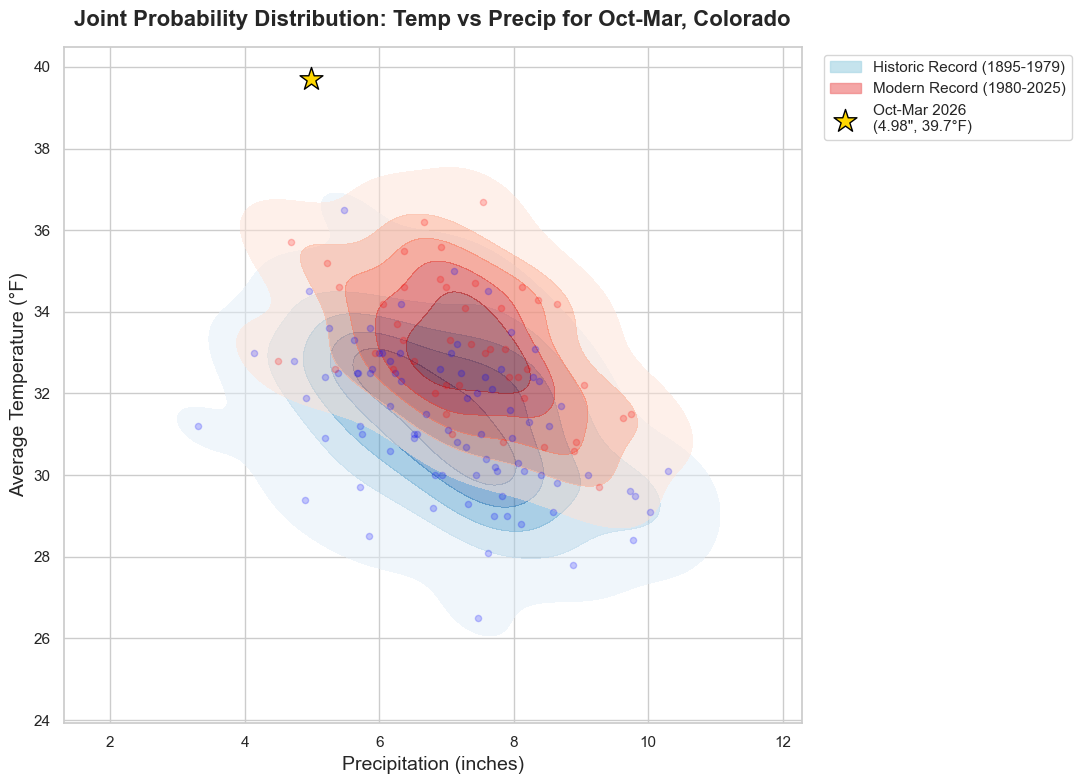

--- Statistical Analysis of March 2026 ---
Compared to the Modern Era (1980-2025):
Temperature: 4.00 standard deviations above average
Precipitation: -1.85 standard deviations from average


In [ ]:
# Let's separate older years from more recent years
df_older = df[df['Year'] < 1980]
df_newer = df[(df['Year'] >= 1980) & (df['Year'] <= 2025)]

# --- VISUALIZATION: JOINT PROBABILITY DISTRIBUTION ---
plt.figure(figsize=(11, 8))
sns.set_theme(style="whitegrid")

# Plot the distribution for the Older Era (Blue)
sns.kdeplot(
    x=df_older['Precip_Value'], 
    y=df_older['Temp_Value'], 
    cmap="Blues", 
    fill=True, 
    alpha=0.5, 
    levels=6, # Number of contour rings
    thresh=0.05 # How far out the lightest shading goes
)

# Plot the distribution for the Newer Era (Red)
sns.kdeplot(
    x=df_newer['Precip_Value'], 
    y=df_newer['Temp_Value'], 
    cmap="Reds", 
    fill=True, 
    alpha=0.5, 
    levels=6, 
    thresh=0.05
)

# Plot the individual points faintly in the background so you can see the actual data
plt.scatter(df_older['Precip_Value'], df_older['Temp_Value'], color='blue', alpha=0.2, s=20)
plt.scatter(df_newer['Precip_Value'], df_newer['Temp_Value'], color='red', alpha=0.2, s=20)

# Highlight 2026
plt.scatter(precip_recent, temp_recent, color='gold', edgecolor='black', s=300, marker='*', zorder=10, label=f'{time_label} {recent_year}\n({precip_recent}", {temp_recent}°F)')

# Customizing the legend (since KDE fill doesn't auto-generate great legends)
import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='lightblue', alpha=0.7, label='Historic Record (1895-1979)')
red_patch = mpatches.Patch(color='lightcoral', alpha=0.7, label='Modern Record (1980-2025)')
plt.legend(handles=[blue_patch, red_patch, plt.gca().get_legend_handles_labels()[0][-1]], loc='upper left', bbox_to_anchor=(1.02, 1))

plt.title(f'Joint Probability Distribution: Temp vs Precip for {time_label}, {state_input}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Precipitation (inches)', fontsize=14)
plt.ylabel('Average Temperature (°F)', fontsize=14)
plt.tight_layout()
outfile = f'images/{state_id}_{month_num}_{timescale_num}_temp_precip_joint_probability.png'
plt.savefig(outfile, dpi=300)
plt.show()


# --- STATISTICAL ANALYSIS: HOW EXTREME IS 2026? ---
print("--- Statistical Analysis of March 2026 ---")

# Calculate Z-Scores (Standard deviations from the mean) relative to the NEWER era
temp_mean_new = df_newer['Temp_Value'].mean()
temp_std_new = df_newer['Temp_Value'].std()
z_temp = (temp_recent - temp_mean_new) / temp_std_new

precip_mean_new = df_newer['Precip_Value'].mean()
precip_std_new = df_newer['Precip_Value'].std()
z_precip = (precip_recent - precip_mean_new) / precip_std_new

print(f"Compared to the Modern Era (1980-2025):")
print(f"Temperature: {z_temp:.2f} standard deviations above average")
print(f"Precipitation: {z_precip:.2f} standard deviations from average")

# A Z-score above 3 is typically considered a statistical outlier (less than 0.3% probability of occurring in a normal distribution).

We're going to translate the z-scores into return intervals. e.g., This monthly anomaly can be expected to occur once every X years.

In [123]:
# Probability of Occurrence

# --- 1. Calculate Z-Scores for the OLDER Era (1895-1979) ---
temp_mean_old = df_older['Temp_Value'].mean()
temp_std_old = df_older['Temp_Value'].std()
z_temp_old = (temp_recent - temp_mean_old) / temp_std_old

precip_mean_old = df_older['Precip_Value'].mean()
precip_std_old = df_older['Precip_Value'].std()
z_precip_old = (precip_recent - precip_mean_old) / precip_std_old


# --- 2. Calculate Probabilities using scipy.stats ---
# stats.norm.sf() calculates the probability of a value being greater than our Z-score
prob_temp_new = stats.norm.sf(z_temp)
prob_precip_new = stats.norm.sf(z_precip)

prob_temp_old = stats.norm.sf(z_temp_old)
prob_precip_old = stats.norm.sf(z_precip_old)

# Helper function to safely format "1 in X years" to avoid dividing by zero
def format_return_period(prob):
    if prob < 0.0000001: 
        return "Virtually Impossible (< 1 in 10,000,000)"
    return f"1 in {int(1/prob):,} years"


# --- 3. Print the Final Report ---
print(f"=== PROBABILITY OF {time_label} {recent_year} CONDITIONS ===")

print("\nCompared to the OLDER Era Baseline (1895-1979):")
print(f"  Temperature Z-Score: {z_temp_old:.2f}")
print(f"  Probability:         {prob_temp_old:.6%} ({format_return_period(prob_temp_old)})")
print(f"  Precip Z-Score:      {z_precip_old:.2f}")
print(f"  Probability:         {prob_precip_old:.6%} ({format_return_period(prob_precip_old)})")

print("\nCompared to the NEWER Era Baseline (1980-2025):")
print(f"  Temperature Z-Score: {z_temp:.2f}")
print(f"  Probability:         {prob_temp_new:.6%} ({format_return_period(prob_temp_new)})")
print(f"  Precip Z-Score:      {z_precip:.2f}")
print(f"  Probability:         {prob_precip_new:.6%} ({format_return_period(prob_precip_new)})")

=== PROBABILITY OF Oct-Mar 2026 CONDITIONS ===

Compared to the OLDER Era Baseline (1895-1979):
  Temperature Z-Score: 4.66
  Probability:         0.000160% (1 in 623,404 years)
  Precip Z-Score:      -1.49
  Probability:         93.151301% (1 in 1 years)

Compared to the NEWER Era Baseline (1980-2025):
  Temperature Z-Score: 4.00
  Probability:         0.003194% (1 in 31,309 years)
  Precip Z-Score:      -1.85
  Probability:         96.814581% (1 in 1 years)


Because precipitation does not follow a normal distribution, these precipitation probabilities are not accurate. Precipitation can't go below 0, so there is not a typical left tail that a normal distribution has. Therefore, we're going to do some additional analysis on the precipitation anomalies to get a better idea on the return interval.

In [124]:
# We're going to fix the precipitation to accurately depict probabilities based on a gamma distribution, rather than the normal distribution we used for temperature.
import scipy.stats as stats

# Assuming you still have 'df_newer', 'df_older', and 'precip_2026' loaded

print("\n=== CORRECTED PRECIPITATION ANALYSIS ===")

# ---------------------------------------------------------
# METHOD 1: The "Left Tail" Normal Distribution Fix
# ---------------------------------------------------------
# Using CDF (Cumulative Distribution Function) for the left tail (dryness)
prob_precip_new_dry = stats.norm.cdf(z_precip)
print(f"\n1. Normal Distribution (Left Tail Fix):")
print(f"   Probability of being this dry or drier: {prob_precip_new_dry:.2%}")
# (This will still underestimate the severity because of the bell curve shape)

# ---------------------------------------------------------
# METHOD 2: Empirical Probability (The Simplest & Most Honest)
# ---------------------------------------------------------
# Just count how many years were actually this dry!
years_this_dry_new = len(df_newer[df_newer['Precip_Value'] <= precip_recent])
total_years_new = len(df_newer)
empirical_prob_new = years_this_dry_new / total_years_new

print(f"\n2. Empirical Probability (Historical Rank):")
print(f"   In the modern era, {years_this_dry_new} out of {total_years_new} years were this dry.")
if empirical_prob_new > 0:
    print(f"   Probability: {empirical_prob_new:.2%} (1 in {int(1/empirical_prob_new)} years)")
else:
    print(f"   Probability: 0.00% (Record breaking!)")

# ---------------------------------------------------------
# METHOD 3: Gamma Distribution (The Scientific Standard)
# ---------------------------------------------------------
# Fit a Gamma curve to the modern precipitation data
fit_alpha, fit_loc, fit_beta = stats.gamma.fit(df_newer['Precip_Value'])

# Calculate the left-tail probability on the Gamma curve
gamma_prob = stats.gamma.cdf(precip_recent, fit_alpha, loc=fit_loc, scale=fit_beta)

print(f"\n3. Gamma Distribution (Climatology Standard):")
print(f"   Probability of being this dry or drier: {gamma_prob:.4%}")
if gamma_prob > 0.0000001:
    print(f"   Return Period: 1 in {int(1/gamma_prob):,} years")



=== CORRECTED PRECIPITATION ANALYSIS ===

1. Normal Distribution (Left Tail Fix):
   Probability of being this dry or drier: 3.19%

2. Empirical Probability (Historical Rank):
   In the modern era, 2 out of 46 years were this dry.
   Probability: 4.35% (1 in 23 years)

3. Gamma Distribution (Climatology Standard):
   Probability of being this dry or drier: 2.8470%
   Return Period: 1 in 35 years


Consider calculating SPI and SPEI based on the data. These could potentially look similar to the gamma distribution calculations above.